# Import the necessary libaries

In [154]:
from sklearn import linear_model, preprocessing

In [3]:
import pandas as pd

In [2]:
from numpy import nan

In [157]:
import pyampute

In [16]:
from typing import Dict, Any, Union, Set, List, Tuple

In [159]:
from math import floor

In [160]:
from pyampute.exploration.mcar_statistical_tests import MCARTest

In [161]:
from pyampute.ampute import MultivariateAmputation

In [22]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

In [1]:
from ucimlrepo import fetch_ucirepo 

In [164]:
import matplotlib.pyplot as plt

# Inspect the datasets with pre-existing missing values

## Look at <code>HCV data</code> (https://archive.ics.uci.edu/dataset/571/hcv+data)

### Preliminary inspection

In [6]:
# fetch dataset 
hcv_data = fetch_ucirepo(id=571) 

In [7]:
hcv_data.metadata

{'uci_id': 571,
 'name': 'HCV data',
 'repository_url': 'https://archive.ics.uci.edu/dataset/571/hcv+data',
 'data_url': 'https://archive.ics.uci.edu/static/public/571/data.csv',
 'abstract': 'The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age.',
 'area': 'Health and Medicine',
 'tasks': ['Classification', 'Clustering'],
 'characteristics': ['Multivariate'],
 'num_instances': 615,
 'num_features': 12,
 'feature_types': ['Integer', 'Real'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['Category'],
 'index_col': ['ID'],
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 2020,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C5D612',
 'creators': ['Ralf Lichtinghagen', 'Frank Klawonn', 'Georg Hoffmann'],
 'intro_paper': {'ID': 237,
  'type': 'NATIVE',
  'title': 'Using machine learning techniques to generate laboratory diagnostic pathways—a case study',
  'authors': 'Geo

In [8]:
type(hcv_data)

ucimlrepo.dotdict.dotdict

In [9]:
print(hcv_data.data.features.head())  # Preview features

   Age Sex   ALB   ALP   AST   BIL    CHE  CHOL   CREA   CGT  PROT   ALT
0   32   m  38.5  52.5  22.1   7.5   6.93  3.23  106.0  12.1  69.0   7.7
1   32   m  38.5  70.3  24.7   3.9  11.17  4.80   74.0  15.6  76.5  18.0
2   32   m  46.9  74.7  52.6   6.1   8.84  5.20   86.0  33.2  79.3  36.2
3   32   m  43.2  52.0  22.6  18.9   7.33  4.74   80.0  33.8  75.7  30.6
4   32   m  39.2  74.1  24.8   9.6   9.15  4.32   76.0  29.9  68.7  32.6


In [10]:
print(hcv_data.data.targets.head())   # Preview targets

        Category
0  0=Blood Donor
1  0=Blood Donor
2  0=Blood Donor
3  0=Blood Donor
4  0=Blood Donor


In [17]:
hcv_data.shape

(615, 12)

### Data pre-processing

In [12]:
X = hcv_data.data.features 

In [13]:
hcv_data = pd.concat([X], axis=1)

In [14]:
hcv_data.head()

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6


In [16]:
hcv_data.describe()

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
count,615.000000,614.000000,597.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000,614.000000
mean,47.408130,41.620195,68.283920,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137,28.450814
std,10.055105,5.780629,26.028315,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636,25.469689
min,19.000000,14.900000,11.300000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000,0.900000
25%,39.000000,38.800000,52.500000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000,16.400000
50%,47.000000,41.950000,66.200000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000,23.000000
75%,54.000000,45.200000,80.100000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000,33.075000
max,77.000000,82.200000,416.600000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000,325.300000


In [371]:
X, y = None, None

#### Count the number of rows without missing values

In [58]:
num_complete_instances = hcv_data.notna().all(axis=1).sum()

In [59]:
num_complete_instances

589

#### Examine the number of complete cases versus total cases

In [60]:
round(num_complete_instances/hcv_data.shape[0], 4)

0.9577

#### Explore the metadata patterns

In [61]:
from pyampute.exploration.md_patterns import mdPatterns

In [62]:
mdPatternGenerator = mdPatterns()

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)


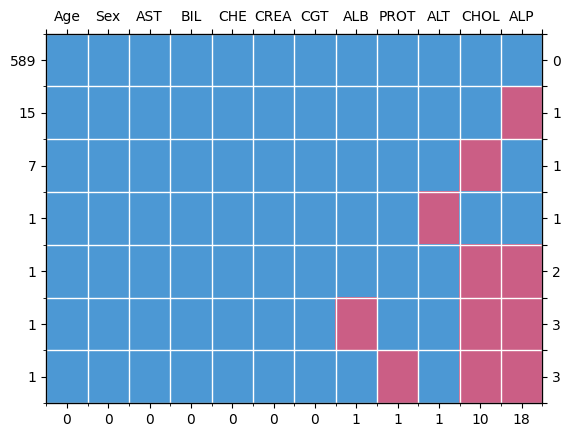

In [63]:
hcv_data_patterns = mdPatternGenerator.get_patterns(hcv_data)

#### Filter out the patients with missing values so that we would have complete baseline values

In [42]:
hcv_data[hcv_data.notna().all(axis=1)].reset_index(drop=True)

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6
...,...,...,...,...,...,...,...,...,...,...,...,...
584,58,f,34.0,46.4,150.0,8.0,6.26,3.98,56.0,49.7,80.6,15.0
585,59,f,39.0,51.3,285.8,40.0,5.77,4.51,136.1,101.1,70.5,19.6
586,62,f,32.0,416.6,110.3,50.0,5.57,6.30,55.7,650.9,68.5,5.9
587,64,f,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9


In [169]:
hcv_data_no_missing = hcv_data[hcv_data.notna().all(axis=1)].reset_index(drop=True).copy()

In [170]:
hcv_data_no_missing.shape

(589, 12)

#### Perform a Little's MCAR statistical test on this dataset [Failed]

In [89]:
mcar_tester = MCARTest(method="little")

In [91]:
print(mcar_tester.little_mcar_test(hcv_data))

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:85: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  gmean = dataset.mean()
/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:86: FutureWarning: The default value of numeric_only in DataFrame.cov is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  gcov = dataset.cov()
/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:104: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future

KeyError: "['Sex'] not in index"

#### Practice one-hot encoding for the attribute "Sex" then

In [195]:
hcv_data_cp = hcv_data.copy()

In [213]:
hcv_data_cp.dtypes

Age       int64
Sex      object
ALB     float64
ALP     float64
AST     float64
BIL     float64
CHE     float64
CHOL    float64
CREA    float64
CGT     float64
PROT    float64
ALT     float64
dtype: object

In [197]:
# create a 0/1 “is_male” column
hcv_data['is_male']   = (hcv_data_cp['Sex'] == 'm').astype(int)

# create a 0/1 “is_female” column
hcv_data['is_female'] = (hcv_data_cp['Sex'] == 'f').astype(int)

In [199]:
hcv_data.drop(["Sex"], axis=1, inplace=True)

In [200]:
hcv_data.dtypes

Age            int64
ALB          float64
ALP          float64
AST          float64
BIL          float64
CHE          float64
CHOL         float64
CREA         float64
CGT          float64
PROT         float64
ALT          float64
is_male        int64
is_female      int64
dtype: object

Perform Little's MCAR test again

In [201]:
print(mcar_tester.little_mcar_test(hcv_data))

0.0


The dataset does not fulfill the requirement of "MCAR"

Again, check the missingness rate of every feature again

In [262]:
complete_attributes: List[str] = []

In [263]:
for col in hcv_data.columns:
    missing_prop = hcv_data[col].isna().sum() / hcv_data.shape[0]
    if not missing_prop > 0:
        complete_attributes.append(col)
    print(f"Missingness of the attribute {col}: {round(missing_prop, 2)}")

Missingness of the attribute Age: 0.0
Missingness of the attribute ALB: 0.0
Missingness of the attribute ALP: 0.03
Missingness of the attribute AST: 0.0
Missingness of the attribute BIL: 0.0
Missingness of the attribute CHE: 0.0
Missingness of the attribute CHOL: 0.02
Missingness of the attribute CREA: 0.0
Missingness of the attribute CGT: 0.0
Missingness of the attribute PROT: 0.0
Missingness of the attribute ALT: 0.0
Missingness of the attribute is_male: 0.0
Missingness of the attribute is_female: 0.0


In [264]:
complete_attributes

['Age', 'AST', 'BIL', 'CHE', 'CREA', 'CGT', 'is_male', 'is_female']

In [209]:
hcv_data.shape

(615, 13)

<b>Conclusion</b>: The missingness rate is extremely small for the two features with missing values. Therefore, we can assign a mask matrix in numpy, then simply impute the missing values via BRR following amputation

Adding an "original" missingness mask

In [364]:
# Boolean mask: True where the entry is missing
missing_mask_HCV_data = hcv_data.isna().to_numpy()
# shape == (n_rows, n_cols), dtype=bool

# If you need 0/1 instead of True/False:
missing_mask_HCV_data = missing_mask_HCV_data.astype(int)

In [365]:
missing_mask_HCV_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]])

In [371]:
missing_mask_HCV_data.shape

(615, 13)

<b> <code>1</code> represents the originally unobserved values, We would like to assign originally observed but artificially amputed values later into <code>2</code> in this mask </b>

#### Practice amputation on the originally observed values then [Failed]

In [217]:
missing_rate = [0.05*rate for rate in range(1, 6)]

In [218]:
missing_rates

(0.05, 0.1, 0.15000000000000002, 0.2, 0.25)

perform amputation using the following reference: https://rianneschouten.github.io/pyampute/build/html/auto_examples/plot_simulation_pipeline.html

##### Create the missing patterns of MAR in the following loop

In [219]:
len(hcv_data.columns)

13

In [220]:
hcv_data.columns

Index(['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT',
       'ALT', 'is_male', 'is_female'],
      dtype='object')

Leave <code>Age</code> as the complete vars, otherwise amputation cannot be done

In [234]:
MAR_pattern = \
[{
    "incomplete_vars": [k for k in range(1, len(hcv_data.columns))],
    "complete_vars": [0],
    "mechanism": "MAR"

}]

In [246]:
amputed_hcv_dfs: List[Tuple[float, pd.DataFrame]] = []

In [ ]:
for missing_rate in missing_rates:
    amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
    amputed_hcv_df = amputor.fit_transform(hcv_data)
    amputed_hcv_dfs.append((missing_rate, amputed_hcv_df))

In [269]:
amputed_hcv_df

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,is_male,is_female
0,32,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7,1.0,0.0
1,32,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0,1.0,0.0
2,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,32,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6,1.0,0.0
4,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
611,64,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9,0.0,1.0
612,64,29.0,87.3,99.0,48.0,1.66,3.63,66.7,64.2,82.0,3.5,0.0,1.0
613,46,33.0,NaN,62.0,20.0,3.56,4.20,52.0,50.0,71.0,39.0,0.0,1.0


<b>Conclusion:</b> unfortunately, we could see that all the features in the same patient gets amputed, this is not what we desired. Therefore, we would have to ampute feature by feature, then replace the processed originally dataset feature by feature 

In [307]:
hcv_data_preprocessed = hcv_data.copy()

In [129]:
amputed_hcv_dfs: List[Tuple[float, pd.DataFrame]] = []

In [273]:
for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed.copy()
    for col in hcv_data_preprocessed.columns:
        MAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MAR"

        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed)
        hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

2025-05-20 11:23:35,313 [WARNING] Failed to load lookup table for a prespecified score to probability function. It is possible data/shift_lookup.csv is missing, in the wrong location, or corrupted. Try rerunning scripts/generate_shift_lookup_table.py to regenerate the lookup table.


AssertionError: Features involved in amputation must be complete, but contains NaNs.

#### Unfortunately, we would have to perform pre-imputation using the Bayesian Ridge Regressor:

In [278]:
# 1) my preprocessed DataFrame with NaNs
df_temp = hcv_data_preprocessed.copy()

# 2) set up the imputer to use BayesianRidge
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,          # number of imputation rounds
    tol=1e-3,             # convergence tolerance
    random_state=0,
)

# 3) fit & transform
imputed_array = imputer.fit_transform(df_temp)

# 4) rewrap into a DataFrame
hcv_data_preprocessed_imputed = pd.DataFrame(imputed_array, columns=df_temp.columns, index=df_temp.index)

In [91]:
# validating the imputation
hcv_data_preprocessed_imputed.notna().all(axis=1).sum() == hcv_data_preprocessed.shape[0]

True

### Perform amputation on the pre-processed and pre-imputed dataset

Let's remember that Sex is essentially one feature, so "is_male" and "is_female" have to be amputed together

In [ ]:
amputed_hcv_dfs = []

for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed_imputed.copy()
    for col in hcv_data_preprocessed_imputed.columns:
        if col == "is_female": continue
        MAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MAR"
        }] if not col == "is_male" else \
        [{
            "incomplete_vars": [col, "is_female"],
            "mechanism": "MAR"
        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed_imputed)
        if not col == "is_male":
            hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
        else:
            hcv_data_temp.loc[:, [col, "is_female"]] = amputed_hcv_df[[col, "is_female"]].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

In [103]:
amputed_hcv_dfs_MAR = amputed_hcv_dfs

In [327]:
amputed_hcv_dfs = None

##### Create the missing patterns of MNAR in the following loop

In [ ]:
amputed_hcv_dfs = []

for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed_imputed.copy()
    for col in hcv_data_preprocessed_imputed.columns:
        if col == "is_female": continue
        MNAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MNAR"
        }] if not col == "is_male" else \
        [{
            "incomplete_vars": [col, "is_female"],
            "mechanism": "MNAR"
        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed_imputed)
        if not col == "is_male":
            hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
        else:
            hcv_data_temp.loc[:, [col, "is_female"]] = amputed_hcv_df[[col, "is_female"]].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

In [108]:
amputed_hcv_dfs_MNAR = amputed_hcv_dfs

In [328]:
amputed_hcv_dfs = None

##### Export the amputed MNAR and MAR dataframes

##### Create the missing patterns of MAR in the following loop

In [113]:
%%bash
mkdir -p amputed_datasets && mkdir -p amputed_datasets/HCV_data

In [114]:
for missing_rate, amputed_df in amputed_hcv_dfs_MAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [115]:
for missing_rate, amputed_df in amputed_hcv_dfs_MNAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)

##### Examination of the exported dataframes

In [320]:
amputed_hcv_df_1 = pd.read_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MNAR_{int(missing_rates[0]*100)}_perc.csv')

In [321]:
amputed_hcv_df_1.isna().sum(axis=0)

Age          40
ALB          44
ALP          43
AST          34
BIL          33
CHE          47
CHOL         37
CREA         26
CGT          41
PROT         44
ALT          41
is_male      32
is_female    32
dtype: int64

In [316]:
amputed_hcv_df_2 = pd.read_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MAR_{int(missing_rates[2]*100)}_perc.csv')

In [317]:
amputed_hcv_df_2.isna().sum(axis=0)

Age           73
ALB          107
ALP          101
AST           79
BIL           97
CHE           88
CHOL          95
CREA          98
CGT           92
PROT          84
ALT           95
is_male       83
is_female     83
dtype: int64

In [310]:
amputed_hcv_df_3 = pd.read_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MAR_{int(missing_rates[-1]*100)}_perc.csv')

In [311]:
amputed_hcv_df_3.isna().sum(axis=0)

Age          160
ALB          154
ALP          148
AST          165
BIL          145
CHE          151
CHOL         159
CREA         172
CGT          150
PROT         151
ALT          143
is_male      133
is_female    133
dtype: int64

##### Examining the original threshold of Sex

In [118]:
hcv_data.notna().all(axis=1).sum()

589

In [119]:
hcv_data['is_male'].sum()

377

In [120]:
hcv_data['is_female'].sum()

238

In [121]:
hcv_data['is_male'].sum() + hcv_data['is_female'].sum() == hcv_data.shape[0]

True

In [122]:
sex_imputation_male_thres = hcv_data['is_male'].sum()/hcv_data.shape[0]

In [123]:
sex_imputation_male_thres

0.6130081300813008

In [124]:
sex_imputation_female_thres = hcv_data['is_female'].sum()/hcv_data.shape[0]

In [125]:
sex_imputation_female_thres

0.38699186991869916

## Look at <code>Regensburg Appendicitis Dataset</code> (https://archive.ics.uci.edu/dataset/938/regensburg+pediatric+appendicitis)

### Preliminary inspection

In [24]:
# fetch dataset 
rgsbg_appendicitis_dataset = fetch_ucirepo(id=938) 
  
# data (as pandas dataframes) 
X = rgsbg_appendicitis_dataset.data.features 
y = rgsbg_appendicitis_dataset.data.targets 

In [25]:
rgsbg_appendicitis_df = pd.concat([X], axis=1)

In [370]:
X, y = None, None

In [70]:
rgsbg_appendicitis_df.shape

(782, 53)

In [27]:
rgsbg_appendicitis_df.describe()

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


Discover more about the metadata patterns of <code>rgsbg_appendicitis_df</code>

In [28]:
from pyampute.exploration.md_patterns import mdPatterns

In [29]:
mdPatternGenerator = mdPatterns()

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)


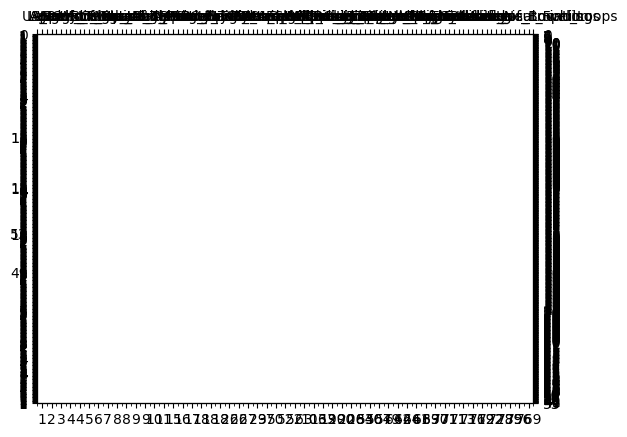

In [232]:
rgsbg_appendicitis_patterns = mdPatternGenerator.get_patterns(rgsbg_appendicitis_df)

It's unfortunately impossible to visualize the missingness pattern in this dataset since there's too much missingness

Instead, we would like to use a dictionary to record the missing rate per feature

In [30]:
rgsbg_appendicitis_df.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay',
       'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US',
       'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia',
       'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria',
       'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign',
       'Appendicolith', 'Perfusion', 'Perforation',
       'Surrounding_Tissue_Reaction', 'Appendicular_Abscess',
       'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location',
       'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus',
       'Coprostasis', 'Me

In [31]:
rgsbg_appendicitis_df.notna().all(axis=1).sum()

0

<b>Conclusion</b>: Unfortunately, filtering out the columns with missing values is not a viable solution here

Examining the missingness per feature

In [32]:
complete_attribute: List[str] = []

In [33]:
for col in rgsbg_appendicitis_df.columns:
    missing_prop = rgsbg_appendicitis_df[col].isna().sum() / rgsbg_appendicitis_df.shape[0]
    if not missing_prop > 0:
        complete_attributes.append(col)
    print(f"Missingness of the attribute {col}: {round(missing_prop, 2)}")

Missingness of the attribute Age: 0.0
Missingness of the attribute BMI: 0.03
Missingness of the attribute Sex: 0.0
Missingness of the attribute Height: 0.03
Missingness of the attribute Weight: 0.0
Missingness of the attribute Length_of_Stay: 0.01
Missingness of the attribute Alvarado_Score: 0.07
Missingness of the attribute Paedriatic_Appendicitis_Score: 0.07
Missingness of the attribute Appendix_on_US: 0.01
Missingness of the attribute Appendix_Diameter: 0.36
Missingness of the attribute Migratory_Pain: 0.01
Missingness of the attribute Lower_Right_Abd_Pain: 0.01
Missingness of the attribute Contralateral_Rebound_Tenderness: 0.02
Missingness of the attribute Coughing_Pain: 0.02
Missingness of the attribute Nausea: 0.01
Missingness of the attribute Loss_of_Appetite: 0.01
Missingness of the attribute Body_Temperature: 0.01
Missingness of the attribute WBC_Count: 0.01
Missingness of the attribute Neutrophil_Percentage: 0.13
Missingness of the attribute Segmented_Neutrophils: 0.93
Missin

In [34]:
complete_attribute

[]

### Data pre-processing

#### Removing the features with extremely high missingness (>80%)

In [71]:
attributes_to_remove: Dict[str, float] = {}

In [72]:
for col in rgsbg_appendicitis_df.columns:
    missing_prop = rgsbg_appendicitis_df[col].isna().sum() / rgsbg_appendicitis_df.shape[0]
    if missing_prop > 0.8:
        attributes_to_remove[col] = round(missing_prop, 4)

In [73]:
attributes_to_remove

{'Segmented_Neutrophils': 0.9309,
 'Target_Sign': 0.8235,
 'Appendicolith': 0.9118,
 'Perfusion': 0.9194,
 'Perforation': 0.8964,
 'Appendicular_Abscess': 0.8913,
 'Abscess_Location': 0.9834,
 'Lymph_Nodes_Location': 0.8453,
 'Bowel_Wall_Thickening': 0.8734,
 'Conglomerate_of_Bowel_Loops': 0.945,
 'Ileus': 0.9233,
 'Coprostasis': 0.9092,
 'Meteorism': 0.821,
 'Enteritis': 0.9156,
 'Gynecological_Findings': 0.9668}

In [74]:
len(attributes_to_remove.keys())

15

In [75]:
appendicitis_df = rgsbg_appendicitis_df.drop(list(attributes_to_remove.keys()), axis=1).copy()

In [76]:
appendicitis_df.shape

(782, 38)

Check the MD pattern of the filtered dataset

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)


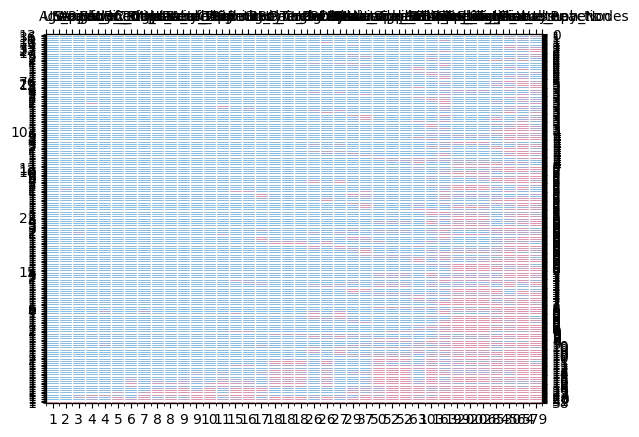

In [77]:
appendicitis_df_md_pattern = mdPatternGenerator.get_patterns(appendicitis_df)

Recheck the overall missingness of this dataset

In [78]:
appendicitis_df.isna().sum(axis=1)

0      0
1      4
2      4
3      3
4      2
      ..
777    6
778    8
779    4
780    1
781    1
Length: 782, dtype: int64

Visualize the number of distributions of unobserved values per row (patient)

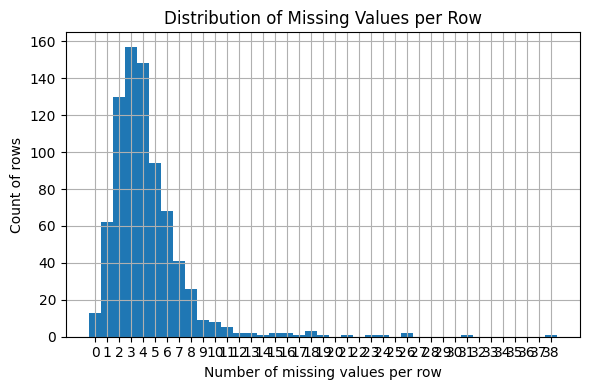

In [79]:
# 1) Compute number of missing values per row
missing_counts = appendicitis_df.isna().sum(axis=1)

# 2) Plot histogram
plt.figure(figsize=(6,4))
plt.hist(
    missing_counts,
    bins=range(missing_counts.min(), missing_counts.max() + 2),
    align='left'
)
plt.xlabel('Number of missing values per row')
plt.ylabel('Count of rows')
plt.title('Distribution of Missing Values per Row')
plt.xticks(range(missing_counts.min(), missing_counts.max() + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

We would like to remove the rows (patients) with more than 20% unobserved values, which could become unmeaningful for imputation

In [80]:
indeces_for_removal: Set[int] = set()

for ind, num_missing in enumerate(appendicitis_df.isna().sum(axis=1)):
    if num_missing > 0.2*appendicitis_df.shape[1]:
        indeces_for_removal.add(ind)

In [81]:
len(indeces_for_removal)

69

In [82]:
appendicitis_df_cp = appendicitis_df.copy()

In [83]:
appendicitis_df = appendicitis_df.drop(index=indeces_for_removal, axis=1).reset_index(drop=True).copy()

In [84]:
appendicitis_df.shape

(713, 38)

In [85]:
appendicitis_df.tail()

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,US_Performed,Free_Fluids,Appendix_Wall_Layers,Surrounding_Tissue_Reaction,Pathological_Lymph_Nodes
708,14.35,19.74,female,151.0,45.0,7.0,4.0,6.0,no,NaN,...,no,diarrhea,local,yes,NaN,yes,no,NaN,NaN,NaN
709,12.41,25.25,female,166.5,70.0,4.0,8.0,7.0,yes,7.5,...,no,diarrhea,local,yes,NaN,yes,no,raised,NaN,NaN
710,14.99,19.91,female,152.0,46.0,4.0,5.0,3.0,no,NaN,...,yes,normal,no,no,no,yes,yes,NaN,NaN,NaN
711,7.20,14.30,male,129.3,23.9,5.0,9.0,8.0,yes,14.0,...,no,normal,local,no,no,yes,yes,NaN,yes,no
712,11.51,18.17,male,146.5,39.0,4.0,2.0,2.0,yes,8.0,...,no,normal,local,no,NaN,yes,no,raised,yes,yes


#### Perform one-hot encoding for the categorical features with sub-80% missingness

In [86]:
appendicitis_df.dtypes

Age                                 float64
BMI                                 float64
Sex                                  object
Height                              float64
Weight                              float64
Length_of_Stay                      float64
Alvarado_Score                      float64
Paedriatic_Appendicitis_Score       float64
Appendix_on_US                       object
Appendix_Diameter                   float64
Migratory_Pain                       object
Lower_Right_Abd_Pain                 object
Contralateral_Rebound_Tenderness     object
Coughing_Pain                        object
Nausea                               object
Loss_of_Appetite                     object
Body_Temperature                    float64
WBC_Count                           float64
Neutrophil_Percentage               float64
Neutrophilia                         object
RBC_Count                           float64
Hemoglobin                          float64
RDW                             

Examine the unique categories of each categorical feature

In [87]:
appendicitis_df["Appendix_on_US"].unique()

array(['yes', 'no'], dtype=object)

In [88]:
appendicitis_df["Ketones_in_Urine"].unique()

array(['++', 'no', '+++', nan, '+'], dtype=object)

In [89]:
set([str(el).lower() for el in appendicitis_df["Appendix_on_US"].unique() if not str(el) == "nan"])

{'no', 'yes'}

In [90]:
cat_var_dict: Dict[str, Set[str]] = dict()

for col, dtype in zip(appendicitis_df.columns, appendicitis_df.dtypes):
    if dtype == "object":
        cat_var_dict[col] = set([str(el).lower() for el in appendicitis_df[col].unique() if not str(el) == "nan"])
        print(col, cat_var_dict[col])

Sex {'male', 'female'}
Appendix_on_US {'no', 'yes'}
Migratory_Pain {'no', 'yes'}
Lower_Right_Abd_Pain {'no', 'yes'}
Contralateral_Rebound_Tenderness {'no', 'yes'}
Coughing_Pain {'no', 'yes'}
Nausea {'no', 'yes'}
Loss_of_Appetite {'no', 'yes'}
Neutrophilia {'no', 'yes'}
Ketones_in_Urine {'+', '+++', 'no', '++'}
RBC_in_Urine {'+++', '+', 'no', '++'}
WBC_in_Urine {'+++', '+', 'no', '++'}
Dysuria {'no', 'yes'}
Stool {'constipation, diarrhea', 'normal', 'diarrhea', 'constipation'}
Peritonitis {'local', 'generalized', 'no'}
Psoas_Sign {'no', 'yes'}
Ipsilateral_Rebound_Tenderness {'no', 'yes'}
US_Performed {'no', 'yes'}
Free_Fluids {'no', 'yes'}
Appendix_Wall_Layers {'raised', 'intact', 'partially raised', 'upset'}
Surrounding_Tissue_Reaction {'no', 'yes'}
Pathological_Lymph_Nodes {'no', 'yes'}


perform one hot encoding then. First of all, we would need to create new columns each feature, then remove the original categorical ones

In [91]:
len(cat_var_dict.items())

22

check the number of valid categorical values

In [92]:
sum_valid_one_hot_encoded_cols = 0

for v in cat_var_dict.values():
    sum_valid_one_hot_encoded_cols += len(v)

EXPECTED_COL_NUMS = appendicitis_df_cp.shape[1] - len(cat_var_dict.items()) + sum_valid_one_hot_encoded_cols
print(EXPECTED_COL_NUMS)

71


In [93]:
appendicitis_df_cp = appendicitis_df.copy()

In [94]:
for k, v in cat_var_dict.items():
    for valid_v in v:
        col = f"{k}-is_{valid_v}"
        mask = (appendicitis_df[k].astype(str).str.lower() == str(valid_v).lower())
        one_hot = mask.astype(int)
        one_hot = one_hot.where(appendicitis_df[k].notna(), other=nan)
        appendicitis_df[col] = one_hot
appendicitis_df.drop(columns=cat_var_dict.keys(), inplace=True)

In [95]:
appendicitis_df.shape[1] == EXPECTED_COL_NUMS

True

In [96]:
appendicitis_df.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP', 'Sex-is_female',
       'Sex-is_male', 'Appendix_on_US-is_yes', 'Appendix_on_US-is_no',
       'Migratory_Pain-is_no', 'Migratory_Pain-is_yes',
       'Lower_Right_Abd_Pain-is_yes', 'Lower_Right_Abd_Pain-is_no',
       'Contralateral_Rebound_Tenderness-is_yes',
       'Contralateral_Rebound_Tenderness-is_no', 'Coughing_Pain-is_no',
       'Coughing_Pain-is_yes', 'Nausea-is_no', 'Nausea-is_yes',
       'Loss_of_Appetite-is_yes', 'Loss_of_Appetite-is_no',
       'Neutrophilia-is_no', 'Neutrophilia-is_yes', 'Ketones_in_Urine-is_++',
       'Ketones_in_Urine-is_no', 'Ketones_in_Urine-is_+++',
       'Ketones_in_Urine-is_+', 'RBC_in_Urine-is_+', 'RBC_in_Urine-is_no',
       'RBC_in_Urine-is_++', 'RBC_in_Urine-is_+++', 'WBC_

Export this one-hot encoded dataset

In [97]:
%%bash
ls .

amputed_datasets
data_preprocessing.ipynb
preprocessed_datasets


In [98]:
%%bash
mkdir -p preprocessed_datasets

In [99]:
appendicitis_df.isna().sum()

Age                                           0
BMI                                          15
Height                                       15
Weight                                        1
Length_of_Stay                                0
                                           ... 
Appendix_Wall_Layers-is_partially raised    500
Surrounding_Tissue_Reaction-is_yes          472
Surrounding_Tissue_Reaction-is_no           472
Pathological_Lymph_Nodes-is_yes             517
Pathological_Lymph_Nodes-is_no              517
Length: 71, dtype: int64

In [ ]:
hcv_data_preprocessed.to_csv("preprocessed_datasets/HCV_data_unimputed.csv", index=False)

In [ ]:
hcv_data_preprocessed_imputed.isna().sum()

In [ ]:
hcv_data_preprocessed_imputed.to_csv("preprocessed_datasets/HCV_data_imputed.csv", index=False)

In [ ]:
appendicitis_df_preprocssed.isna().sum()

In [ ]:
appendicitis_df_preprocssed.to_csv("preprocessed_datasets/Regensburg_Pediatric_Appendicitis_unimputed.csv", index=False)

#### Perform pre-imputation on the <code>appendicitis_df</code>

In [337]:
# 1) my preprocessed DataFrame with NaNs
df_temp = appendicitis_df_preprocessed.copy()

# 2) set up the imputer to use BayesianRidge
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,          # number of imputation rounds
    tol=1e-3,             # convergence tolerance
    random_state=0,
)

# 3) fit & transform
imputed_array = imputer.fit_transform(df_temp)

# 4) rewrap into a DataFrame
appendicitis_df_preprocessed_imputed = pd.DataFrame(imputed_array, columns=df_temp.columns, index=df_temp.index)

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [103]:
df_temp = None

In [102]:
appendicitis_df_preprocessed_imputed.notna().sum(axis=1).all()

True

In [105]:
appendicitis_df_preprocessed_imputed.tail()

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,...,Free_Fluids-is_no,Free_Fluids-is_yes,Appendix_Wall_Layers-is_intact,Appendix_Wall_Layers-is_raised,Appendix_Wall_Layers-is_upset,Appendix_Wall_Layers-is_partially raised,Surrounding_Tissue_Reaction-is_yes,Surrounding_Tissue_Reaction-is_no,Pathological_Lymph_Nodes-is_yes,Pathological_Lymph_Nodes-is_no
708,14.35,19.74,151.0,45.0,7.0,4.0,6.0,6.926934,38.0,8.8,...,1.0,0.0,0.615023,0.342723,0.004695,0.037559,0.821577,0.178423,0.765306,0.234694
709,12.41,25.25,166.5,70.0,4.0,8.0,7.0,7.500000,39.4,11.4,...,1.0,0.0,0.000000,1.000000,0.000000,0.000000,0.821577,0.178423,0.765306,0.234694
710,14.99,19.91,152.0,46.0,4.0,5.0,3.0,7.387729,37.3,14.6,...,0.0,1.0,0.615023,0.342723,0.004695,0.037559,0.821577,0.178423,0.765306,0.234694
711,7.20,14.30,129.3,23.9,5.0,9.0,8.0,14.000000,37.5,17.8,...,0.0,1.0,0.615024,0.342723,0.004695,0.037558,1.000000,0.000000,0.000000,1.000000
712,11.51,18.17,146.5,39.0,4.0,2.0,2.0,8.000000,36.8,9.3,...,1.0,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000


In [406]:
appendicitis_df_preprocessed_imputed.to_csv("preprocessed_datasets/Regensburg_Pediatric_Appendicitis_imputed.csv", index=False)

#### Create an original missingness mask on the pre-processed but unimputed dataset

In [65]:
appendicitis_df_preprocessed_imputed = pd.read_csv("preprocessed_datasets/Regensburg_Pediatric_Appendicitis_imputed.csv")

In [66]:
appendicitis_df = pd.read_csv("preprocessed_datasets/Regensburg_Pediatric_Appendicitis_unimputed.csv")

In [106]:
appendicitis_df.tail()

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,...,Free_Fluids-is_no,Free_Fluids-is_yes,Appendix_Wall_Layers-is_intact,Appendix_Wall_Layers-is_raised,Appendix_Wall_Layers-is_upset,Appendix_Wall_Layers-is_partially raised,Surrounding_Tissue_Reaction-is_yes,Surrounding_Tissue_Reaction-is_no,Pathological_Lymph_Nodes-is_yes,Pathological_Lymph_Nodes-is_no
708,14.35,19.74,151.0,45.0,7.0,4.0,6.0,NaN,38.0,8.8,...,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
709,12.41,25.25,166.5,70.0,4.0,8.0,7.0,7.5,39.4,11.4,...,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
710,14.99,19.91,152.0,46.0,4.0,5.0,3.0,NaN,37.3,14.6,...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
711,7.20,14.30,129.3,23.9,5.0,9.0,8.0,14.0,37.5,17.8,...,0.0,1.0,NaN,NaN,NaN,NaN,1.0,0.0,0.0,1.0
712,11.51,18.17,146.5,39.0,4.0,2.0,2.0,8.0,36.8,9.3,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [16]:
# Boolean mask: True where the entry is missing
missing_mask_Appenditictis = appendicitis_df.isna().to_numpy()
# shape == (n_rows, n_cols), dtype=bool

# If you need 0/1 instead of True/False:
missing_mask_Appenditictis = missing_mask_Appenditictis.astype(int)

In [17]:
missing_mask_Appenditictis

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [112]:
missing_mask_Appenditictis.shape == appendicitis_df.shape == appendicitis_df_preprocessed_imputed.shape

True

### Perform amputation on the pre-processed and pre-imputed dataset

In [108]:
missing_rates = [0.05*k for k in range(1, 6)]
missing_rates

[0.05, 0.1, 0.15000000000000002, 0.2, 0.25]

Let's remember that the one-hot encoded columns of each categorical feature must be amputed together to yield meaningful results

Take a look about how to match the column names

In [111]:
appendicitis_df_preprocessed_imputed.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP', 'Sex-is_female',
       'Sex-is_male', 'Appendix_on_US-is_yes', 'Appendix_on_US-is_no',
       'Migratory_Pain-is_no', 'Migratory_Pain-is_yes',
       'Lower_Right_Abd_Pain-is_yes', 'Lower_Right_Abd_Pain-is_no',
       'Contralateral_Rebound_Tenderness-is_yes',
       'Contralateral_Rebound_Tenderness-is_no', 'Coughing_Pain-is_no',
       'Coughing_Pain-is_yes', 'Nausea-is_no', 'Nausea-is_yes',
       'Loss_of_Appetite-is_yes', 'Loss_of_Appetite-is_no',
       'Neutrophilia-is_no', 'Neutrophilia-is_yes', 'Ketones_in_Urine-is_++',
       'Ketones_in_Urine-is_no', 'Ketones_in_Urine-is_+++',
       'Ketones_in_Urine-is_+', 'RBC_in_Urine-is_+', 'RBC_in_Urine-is_no',
       'RBC_in_Urine-is_++', 'RBC_in_Urine-is_+++', 'WBC_

In [149]:
len(appendicitis_df_preprocessed_imputed.columns)

71

In [205]:
appendicitis_df_preprocessed_imputed.columns[appendicitis_df_preprocessed_imputed.columns.str.match(".+-is_.+")]

Index(['Sex-is_female', 'Sex-is_male', 'Appendix_on_US-is_yes',
       'Appendix_on_US-is_no', 'Migratory_Pain-is_no', 'Migratory_Pain-is_yes',
       'Lower_Right_Abd_Pain-is_yes', 'Lower_Right_Abd_Pain-is_no',
       'Contralateral_Rebound_Tenderness-is_yes',
       'Contralateral_Rebound_Tenderness-is_no', 'Coughing_Pain-is_no',
       'Coughing_Pain-is_yes', 'Nausea-is_no', 'Nausea-is_yes',
       'Loss_of_Appetite-is_yes', 'Loss_of_Appetite-is_no',
       'Neutrophilia-is_no', 'Neutrophilia-is_yes', 'Ketones_in_Urine-is_++',
       'Ketones_in_Urine-is_no', 'Ketones_in_Urine-is_+++',
       'Ketones_in_Urine-is_+', 'RBC_in_Urine-is_+', 'RBC_in_Urine-is_no',
       'RBC_in_Urine-is_++', 'RBC_in_Urine-is_+++', 'WBC_in_Urine-is_no',
       'WBC_in_Urine-is_+', 'WBC_in_Urine-is_+++', 'WBC_in_Urine-is_++',
       'Dysuria-is_no', 'Dysuria-is_yes', 'Stool-is_normal',
       'Stool-is_constipation', 'Stool-is_diarrhea',
       'Stool-is_constipation, diarrhea', 'Peritonitis-is_no',
     

In [206]:
cat_cols = list(appendicitis_df_preprocessed_imputed.columns[appendicitis_df_preprocessed_imputed.columns.str.match(".+-is_.+")])

In [207]:
non_cat_cols = list(appendicitis_df_preprocessed_imputed.columns[~appendicitis_df_preprocessed_imputed.columns.str.match(".+-is_.+")])

In [208]:
cat_var_dict: Dict[str, Set[str]] = dict()

In [209]:
for col in cat_cols:
    base_col = col.split("-")[0]
    if base_col not in cat_var_dict:
        cat_var_dict[base_col] = set()
    cat_val = col.split("_")[-1]
    cat_var_dict[base_col].add(cat_val)

In [265]:
cat_var_dict

{'Sex': {'female', 'male'},
 'Appendix_on_US': {'no', 'yes'},
 'Migratory_Pain': {'no', 'yes'},
 'Lower_Right_Abd_Pain': {'no', 'yes'},
 'Contralateral_Rebound_Tenderness': {'no', 'yes'},
 'Coughing_Pain': {'no', 'yes'},
 'Nausea': {'no', 'yes'},
 'Loss_of_Appetite': {'no', 'yes'},
 'Neutrophilia': {'no', 'yes'},
 'Ketones_in_Urine': {'+', '++', '+++', 'no'},
 'RBC_in_Urine': {'+', '++', '+++', 'no'},
 'WBC_in_Urine': {'+', '++', '+++', 'no'},
 'Dysuria': {'no', 'yes'},
 'Stool': {'constipation', 'constipation, diarrhea', 'diarrhea', 'normal'},
 'Peritonitis': {'generalized', 'local', 'no'},
 'Psoas_Sign': {'no', 'yes'},
 'Ipsilateral_Rebound_Tenderness': {'no', 'yes'},
 'US_Performed': {'no', 'yes'},
 'Free_Fluids': {'no', 'yes'},
 'Appendix_Wall_Layers': {'intact', 'partially raised', 'raised', 'upset'},
 'Surrounding_Tissue_Reaction': {'no', 'yes'},
 'Pathological_Lymph_Nodes': {'no', 'yes'}}

#### Perform MAR amputation

In [ ]:
amputed_appendicitis_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_appendicitis_df = appendicitis_df_preprocessed_imputed.copy()
    amputed_cat_vars: Set[str] = set()
    for col in appendicitis_df_preprocessed_imputed.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a categorical feature
            MAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_appendicitis_df[col] = amputor.fit_transform(appendicitis_df_preprocessed_imputed)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_appendicitis_df[vars_to_ampute] = \
            amputor.fit_transform(appendicitis_df_preprocessed_imputed)[vars_to_ampute].values
        else:
            continue
    
    amputed_appendicitis_dfs.append((missing_rate, amputed_appendicitis_df))
    amputed_appendicitis_df = None

In [301]:
amputed_appendicitis_dfs[0][-1][non_cat_cols].isna().sum(axis=0)

Age                              61
BMI                              51
Height                           47
Weight                           55
Length_of_Stay                   54
Alvarado_Score                   54
Paedriatic_Appendicitis_Score    53
Appendix_Diameter                43
Body_Temperature                 61
WBC_Count                        40
Neutrophil_Percentage            61
RBC_Count                        49
Hemoglobin                       55
RDW                              53
Thrombocyte_Count                57
CRP                              52
dtype: int64

In [300]:
amputed_appendicitis_dfs[0][-1][cat_cols].isna().sum(axis=0)

Sex-is_female                               61
Sex-is_male                                 61
Appendix_on_US-is_yes                       56
Appendix_on_US-is_no                        56
Migratory_Pain-is_no                        54
Migratory_Pain-is_yes                       54
Lower_Right_Abd_Pain-is_yes                 44
Lower_Right_Abd_Pain-is_no                  44
Contralateral_Rebound_Tenderness-is_yes     56
Contralateral_Rebound_Tenderness-is_no      56
Coughing_Pain-is_no                         35
Coughing_Pain-is_yes                        35
Nausea-is_no                                56
Nausea-is_yes                               56
Loss_of_Appetite-is_yes                     47
Loss_of_Appetite-is_no                      47
Neutrophilia-is_no                          55
Neutrophilia-is_yes                         55
Ketones_in_Urine-is_++                      48
Ketones_in_Urine-is_no                      48
Ketones_in_Urine-is_+++                     48
Ketones_in_Ur

In [323]:
amputed_appendicitis_dfs[-1][-1][non_cat_cols].isna().sum(axis=0)

Age                              175
BMI                              179
Height                           186
Weight                           158
Length_of_Stay                   185
Alvarado_Score                   181
Paedriatic_Appendicitis_Score    167
Appendix_Diameter                194
Body_Temperature                 183
WBC_Count                        174
Neutrophil_Percentage            172
RBC_Count                        176
Hemoglobin                       175
RDW                              194
Thrombocyte_Count                187
CRP                              163
dtype: int64

In [324]:
amputed_appendicitis_dfs[-1][-1][cat_cols].isna().sum(axis=0)

Sex-is_female                               174
Sex-is_male                                 174
Appendix_on_US-is_yes                       165
Appendix_on_US-is_no                        165
Migratory_Pain-is_no                        169
Migratory_Pain-is_yes                       169
Lower_Right_Abd_Pain-is_yes                 162
Lower_Right_Abd_Pain-is_no                  162
Contralateral_Rebound_Tenderness-is_yes     187
Contralateral_Rebound_Tenderness-is_no      187
Coughing_Pain-is_no                         178
Coughing_Pain-is_yes                        178
Nausea-is_no                                187
Nausea-is_yes                               187
Loss_of_Appetite-is_yes                     178
Loss_of_Appetite-is_no                      178
Neutrophilia-is_no                          177
Neutrophilia-is_yes                         177
Ketones_in_Urine-is_++                      173
Ketones_in_Urine-is_no                      173
Ketones_in_Urine-is_+++                 

In [325]:
amputed_appendicitis_MAR_dfs = amputed_appendicitis_dfs

In [326]:
amputed_appendicitis_dfs = None

#### Perform MNAR amputation

In [ ]:
amputed_appendicitis_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_appendicitis_df = appendicitis_df_preprocessed_imputed.copy()
    amputed_cat_vars: Set[str] = set()
    for col in appendicitis_df_preprocessed_imputed.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a categorical feature
            MNAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_appendicitis_df[col] = amputor.fit_transform(appendicitis_df_preprocessed_imputed)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MNAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_appendicitis_df[vars_to_ampute] = \
            amputor.fit_transform(appendicitis_df_preprocessed_imputed)[vars_to_ampute].values
        else:
            continue
    
    amputed_appendicitis_dfs.append((missing_rate, amputed_appendicitis_df))
    amputed_appendicitis_df = None

In [340]:
amputed_appendicitis_dfs[0][-1][non_cat_cols].isna().sum(axis=0)

Age                              48
BMI                              43
Height                           53
Weight                           43
Length_of_Stay                   57
Alvarado_Score                   43
Paedriatic_Appendicitis_Score    61
Appendix_Diameter                38
Body_Temperature                 46
WBC_Count                        58
Neutrophil_Percentage            54
RBC_Count                        31
Hemoglobin                       47
RDW                              30
Thrombocyte_Count                51
CRP                              56
dtype: int64

In [341]:
amputed_appendicitis_dfs[0][-1][cat_cols].isna().sum(axis=0)

Sex-is_female                               26
Sex-is_male                                 26
Appendix_on_US-is_yes                       42
Appendix_on_US-is_no                        42
Migratory_Pain-is_no                        38
Migratory_Pain-is_yes                       38
Lower_Right_Abd_Pain-is_yes                 37
Lower_Right_Abd_Pain-is_no                  37
Contralateral_Rebound_Tenderness-is_yes     28
Contralateral_Rebound_Tenderness-is_no      28
Coughing_Pain-is_no                         44
Coughing_Pain-is_yes                        44
Nausea-is_no                                31
Nausea-is_yes                               31
Loss_of_Appetite-is_yes                     43
Loss_of_Appetite-is_no                      43
Neutrophilia-is_no                          42
Neutrophilia-is_yes                         42
Ketones_in_Urine-is_++                      49
Ketones_in_Urine-is_no                      49
Ketones_in_Urine-is_+++                     49
Ketones_in_Ur

In [345]:
amputed_appendicitis_dfs[-1][-1][non_cat_cols].isna().sum(axis=0)

Age                              196
BMI                              178
Height                           179
Weight                           170
Length_of_Stay                   159
Alvarado_Score                   164
Paedriatic_Appendicitis_Score    204
Appendix_Diameter                176
Body_Temperature                 196
WBC_Count                        169
Neutrophil_Percentage            162
RBC_Count                        188
Hemoglobin                       174
RDW                              166
Thrombocyte_Count                154
CRP                              183
dtype: int64

In [346]:
amputed_appendicitis_dfs[-1][-1][cat_cols].isna().sum(axis=0)

Sex-is_female                               176
Sex-is_male                                 176
Appendix_on_US-is_yes                       175
Appendix_on_US-is_no                        175
Migratory_Pain-is_no                        163
Migratory_Pain-is_yes                       163
Lower_Right_Abd_Pain-is_yes                 178
Lower_Right_Abd_Pain-is_no                  178
Contralateral_Rebound_Tenderness-is_yes     199
Contralateral_Rebound_Tenderness-is_no      199
Coughing_Pain-is_no                         170
Coughing_Pain-is_yes                        170
Nausea-is_no                                179
Nausea-is_yes                               179
Loss_of_Appetite-is_yes                     173
Loss_of_Appetite-is_no                      173
Neutrophilia-is_no                          181
Neutrophilia-is_yes                         181
Ketones_in_Urine-is_++                      187
Ketones_in_Urine-is_no                      187
Ketones_in_Urine-is_+++                 

In [347]:
amputed_appendicitis_MNAR_dfs = amputed_appendicitis_dfs

In [348]:
amputed_appendicitis_dfs = None

#### Export the amputed datasets

In [350]:
%%bash
ls .

amputed_datasets
data_preprocessing.ipynb
preprocessed_datasets


In [351]:
%%bash
mkdir -p amputed_datasets/appendicitis_data

In [352]:
for missing_rate, amputed_df in amputed_appendicitis_MAR_dfs:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [353]:
for missing_rate, amputed_df in amputed_appendicitis_MNAR_dfs:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)

In [355]:
%%bash
du -sh amputed_datasets/*/

348K	amputed_datasets/HCV_data/
2.6M	amputed_datasets/appendicitis_data/


In [358]:
%%bash
du -sh amputed_datasets/HCV_data/*

 36K	amputed_datasets/HCV_data/hcv_data_amputed_MAR_10_perc.csv
 36K	amputed_datasets/HCV_data/hcv_data_amputed_MAR_15_perc.csv
 32K	amputed_datasets/HCV_data/hcv_data_amputed_MAR_20_perc.csv
 32K	amputed_datasets/HCV_data/hcv_data_amputed_MAR_25_perc.csv
 36K	amputed_datasets/HCV_data/hcv_data_amputed_MAR_5_perc.csv
 36K	amputed_datasets/HCV_data/hcv_data_amputed_MNAR_10_perc.csv
 36K	amputed_datasets/HCV_data/hcv_data_amputed_MNAR_15_perc.csv
 32K	amputed_datasets/HCV_data/hcv_data_amputed_MNAR_20_perc.csv
 32K	amputed_datasets/HCV_data/hcv_data_amputed_MNAR_25_perc.csv
 40K	amputed_datasets/HCV_data/hcv_data_amputed_MNAR_5_perc.csv


In [357]:
%%bash
du -sh amputed_datasets/appendicitis_data/*

280K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_10_perc.csv
268K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_15_perc.csv
256K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_20_perc.csv
244K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_25_perc.csv
288K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MAR_5_perc.csv
284K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_10_perc.csv
272K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_15_perc.csv
256K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_20_perc.csv
244K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_25_perc.csv
292K	amputed_datasets/appendicitis_data/appendicitis_data_amputed_MNAR_5_perc.csv


# Inspect the datasets without pre-existing missing values

## Look at <code>Heart Failure Clinical Records</code> (https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records)

### Preliminary inspection

In [401]:
# fetch dataset 
heart_failure_dataset = fetch_ucirepo(id=519) 
  
# data (as pandas dataframes) 
X = heart_failure_dataset.data.features 
y = heart_failure_dataset.data.targets 

In [402]:
heart_failure_df = pd.concat([X], axis=1)

In [403]:
X, y = None, None

In [404]:
heart_failure_df.isna().sum(axis=0) 

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
dtype: int64

<b>Conclusion</b>: No missingness in this dataset!

In [405]:
heart_failure_df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
dtype: object

In [406]:
heart_failure_df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000


<b>Observation:</b> although all the columns are classified as <code>int64</code> or <code>float64</code> datatype, its quite obvious that there are a couple of binary features 

In [407]:
heart_failure_df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')

In [408]:
binary_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

### Data pre-processing

Since this dataset doesn't have pre-existing missingness, pre-imputation isn't necessary, we can directly perform one-hot encoding

In [409]:
binary_var_dict: Dict[str, List[str]] = {
    "anaemia": ["no", "yes"],
    "diabetes": ["no", "yes"],
    "high_blood_pressure": ["no", "yes"],
    "sex": ["female", "male"],
    "smoking": ["no", "yes"]
}

In [410]:
for k, v in binary_var_dict.items():
    for i, valid_v in enumerate(v):
        col = f"{k}-is_{valid_v}"
        mask = (heart_failure_df[k].astype(int) == int(i))
        one_hot = mask.astype(int)
        one_hot = one_hot.where(heart_failure_df[k].notna(), other=nan)
        heart_failure_df[col] = one_hot
heart_failure_df.drop(columns=binary_var_dict.keys(), inplace=True)

In [411]:
heart_failure_df

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia-is_no,anaemia-is_yes,diabetes-is_no,diabetes-is_yes,high_blood_pressure-is_no,high_blood_pressure-is_yes,sex-is_female,sex-is_male,smoking-is_no,smoking-is_yes
0,75.0,582,20,265000.00,1.9,130,4,1,0,1,0,0,1,0,1,1,0
1,55.0,7861,38,263358.03,1.1,136,6,1,0,1,0,1,0,0,1,1,0
2,65.0,146,20,162000.00,1.3,129,7,1,0,1,0,1,0,0,1,0,1
3,50.0,111,20,210000.00,1.9,137,7,0,1,1,0,1,0,0,1,1,0
4,65.0,160,20,327000.00,2.7,116,8,0,1,0,1,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,61,38,155000.00,1.1,143,270,1,0,0,1,0,1,0,1,0,1
295,55.0,1820,38,270000.00,1.2,139,271,1,0,1,0,1,0,1,0,1,0
296,45.0,2060,60,742000.00,0.8,138,278,1,0,0,1,1,0,1,0,1,0
297,45.0,2413,38,140000.00,1.4,140,280,1,0,1,0,1,0,0,1,0,1


Export the pre-processed dataset as csv

In [413]:
%%bash
ls preprocessed_datasets/

HCV_data_imputed.csv
HCV_data_unimputed.csv
Regensburg_Pediatric_Appendicitis_imputed.csv
Regensburg_Pediatric_Appendicitis_unimputed.csv


In [414]:
heart_failure_df.to_csv("preprocessed_datasets/Heart_Failure_Clinical_Records_complete.csv", index=False)

In [415]:
%%bash
head -n 5 preprocessed_datasets/Heart_Failure_Clinical_Records_complete.csv

age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia-is_no,anaemia-is_yes,diabetes-is_no,diabetes-is_yes,high_blood_pressure-is_no,high_blood_pressure-is_yes,sex-is_female,sex-is_male,smoking-is_no,smoking-is_yes
75.0,582,20,265000.0,1.9,130,4,1,0,1,0,0,1,0,1,1,0
55.0,7861,38,263358.03,1.1,136,6,1,0,1,0,1,0,0,1,1,0
65.0,146,20,162000.0,1.3,129,7,1,0,1,0,1,0,0,1,0,1
50.0,111,20,210000.0,1.9,137,7,0,1,1,0,1,0,0,1,1,0


### Perform amputation on the pre-processed dataset

In [431]:
missing_rates = [0.05 * k for k in range(1, 6)]

#### Perform MAR amputation

In [ ]:
amputed_heart_failure_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_heart_failure_df = heart_failure_df.copy()
    amputed_bi_vars: Set[str] = set()
    for col in heart_failure_df.columns:
        base_col = col.split("-")[0]
        if base_col not in binary_var_dict: # if it's not a binary/categorical feature
            MAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_heart_failure_df[col] = amputor.fit_transform(heart_failure_df)[col].values
        elif base_col in binary_var_dict and base_col not in amputed_bi_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in binary_var_dict[base_col]]
            amputed_bi_vars.add(base_col)
            MAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_heart_failure_df[vars_to_ampute] = amputor.fit_transform(heart_failure_df)[vars_to_ampute].values
        else:
            continue
    
    amputed_heart_failure_dfs.append((missing_rate, amputed_heart_failure_df))
    amputed_heart_failure_df = None

In [439]:
amputed_heart_failure_dfs[0][1].shape

(299, 17)

In [438]:
amputed_heart_failure_dfs[0][1].isna().sum(axis=0)

age                           22
creatinine_phosphokinase      24
ejection_fraction             24
platelets                     20
serum_creatinine              23
serum_sodium                  29
time                          22
anaemia-is_no                 20
anaemia-is_yes                20
diabetes-is_no                19
diabetes-is_yes               19
high_blood_pressure-is_no     17
high_blood_pressure-is_yes    17
sex-is_female                 18
sex-is_male                   18
smoking-is_no                 22
smoking-is_yes                22
dtype: int64

In [441]:
amputed_heart_failure_dfs[4][1].isna().sum(axis=0)

age                           71
creatinine_phosphokinase      77
ejection_fraction             54
platelets                     79
serum_creatinine              73
serum_sodium                  87
time                          77
anaemia-is_no                 68
anaemia-is_yes                68
diabetes-is_no                86
diabetes-is_yes               86
high_blood_pressure-is_no     79
high_blood_pressure-is_yes    79
sex-is_female                 67
sex-is_male                   67
smoking-is_no                 70
smoking-is_yes                70
dtype: int64

In [442]:
amputed_heart_failure_dfs_MAR = amputed_heart_failure_dfs

In [443]:
amputed_heart_failure_dfs = None

#### Perform MNAR amputation

In [ ]:
amputed_heart_failure_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_heart_failure_df = heart_failure_df.copy()
    amputed_bi_vars: Set[str] = set()
    for col in heart_failure_df.columns:
        base_col = col.split("-")[0]
        if base_col not in binary_var_dict: # if it's not a binary/categorical feature
            MNAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_heart_failure_df[col] = amputor.fit_transform(heart_failure_df)[col].values
        elif base_col in binary_var_dict and base_col not in amputed_bi_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in binary_var_dict[base_col]]
            amputed_bi_vars.add(base_col)
            MNAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_heart_failure_df[vars_to_ampute] = amputor.fit_transform(heart_failure_df)[vars_to_ampute].values
        else:
            continue
    
    amputed_heart_failure_dfs.append((missing_rate, amputed_heart_failure_df))
    amputed_heart_failure_df = None

In [445]:
amputed_heart_failure_dfs_MNAR = amputed_heart_failure_dfs

In [446]:
amputed_heart_failure_dfs = None

In [448]:
amputed_heart_failure_dfs_MNAR[0][1].isna().sum(axis=0)

age                           24
creatinine_phosphokinase      17
ejection_fraction             16
platelets                     23
serum_creatinine              17
serum_sodium                  18
time                          20
anaemia-is_no                 11
anaemia-is_yes                11
diabetes-is_no                12
diabetes-is_yes               12
high_blood_pressure-is_no     15
high_blood_pressure-is_yes    15
sex-is_female                 12
sex-is_male                   12
smoking-is_no                 18
smoking-is_yes                18
dtype: int64

In [449]:
amputed_heart_failure_dfs_MNAR[4][1].isna().sum(axis=0)

age                           69
creatinine_phosphokinase      77
ejection_fraction             81
platelets                     71
serum_creatinine              79
serum_sodium                  92
time                          77
anaemia-is_no                 65
anaemia-is_yes                65
diabetes-is_no                66
diabetes-is_yes               66
high_blood_pressure-is_no     70
high_blood_pressure-is_yes    70
sex-is_female                 83
sex-is_male                   83
smoking-is_no                 82
smoking-is_yes                82
dtype: int64

#### Export the amputed Heart Failure Datasets

In [450]:
%%bash
mkdir -p amputed_datasets/heart_failure_clinical_records

In [451]:
for missing_rate, amputed_df in amputed_heart_failure_dfs_MAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/heart_failure_clinical_records/heart_failure_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [452]:
for missing_rate, amputed_df in amputed_heart_failure_dfs_MNAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/heart_failure_clinical_records/heart_failure_data_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)

## Look at <code>Hepatitis C Virus (HCV) for Egyptian patients
</code> (https://archive.ics.uci.edu/dataset/503/hepatitis+c+virus+hcv+for+egyptian+patients)

### Preliminary inspection

In [13]:
# fetch dataset 
hcv_egyptian_dataset = fetch_ucirepo(id=503) 
  
# data (as pandas dataframes) 
X = hcv_egyptian_dataset.data.features  
y = hcv_egyptian_dataset.data.targets 

In [14]:
hcv_egyptian_df = pd.concat([X], axis=1)

In [15]:
hcv_egyptian_df.shape

(1385, 28)

In [16]:
hcv_egyptian_df.isna().sum(axis=0)

Age                                 0
Gender                              0
BMI                                 0
Fever                               0
Nausea/Vomting                      0
Headache                            0
Diarrhea                            0
Fatigue & generalized bone ache     0
Jaundice                            0
Epigastric pain                     0
WBC                                 0
RBC                                 0
HGB                                 0
Plat                                0
AST 1                               0
ALT 1                               0
ALT4                                0
ALT 12                              0
ALT 24                              0
ALT 36                              0
ALT 48                              0
ALT after 24 w                      0
RNA Base                            0
RNA 4                               0
RNA 12                              0
RNA EOT                             0
RNA EF      

<b>Conclusion:</b> no missing data observed

In [17]:
hcv_egyptian_df.columns

Index(['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ',
       'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ',
       'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1',
       'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w',
       'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF',
       'Baseline histological Grading'],
      dtype='object')

In [18]:
hcv_egyptian_df.describe()

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 24,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,...,83.709025,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,...,26.205994,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,39.000000,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,61.000000,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,83.000000,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,107.000000,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,128.000000,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000


In [19]:
hcv_egyptian_df["Baseline histological Grading"].astype(str).unique()

array(['13', '4', '10', '11', '12', '5', '15', '16', '8', '9', '3', '6',
       '7', '14'], dtype=object)

In [20]:
hcv_egyptian_df["Baseline histological Grading"].dtype

dtype('int64')

In [21]:
hcv_egyptian_df.isna().sum(axis=0)

Age                                 0
Gender                              0
BMI                                 0
Fever                               0
Nausea/Vomting                      0
Headache                            0
Diarrhea                            0
Fatigue & generalized bone ache     0
Jaundice                            0
Epigastric pain                     0
WBC                                 0
RBC                                 0
HGB                                 0
Plat                                0
AST 1                               0
ALT 1                               0
ALT4                                0
ALT 12                              0
ALT 24                              0
ALT 36                              0
ALT 48                              0
ALT after 24 w                      0
RNA Base                            0
RNA 4                               0
RNA 12                              0
RNA EOT                             0
RNA EF      

THere are obsiovusly lots of categorical variables

### Data pre-processing

Since this dataset doesn't have pre-existing missingness, pre-imputation isn't necessary, we can directly perform one-hot encoding

In [22]:
cat_var_dict = {
    "Gender": ["male", "female"],
    "Fever": ["no", "yes"],
    "Nausea/Vomting": ["no", "yes"],
    "Headache ": ["no", "yes"],
    "Diarrhea ": ["no", "yes"],
    "Fatigue & generalized bone ache ": ["no", "yes"],
    "Jaundice ": ["no", "yes"],
    "Epigastric pain ": ["no", "yes"],
    "Baseline histological Grading": ['13', '4', '10', '11', '12', '5', '15', '16', '8', '9', '3', '6', '7', '14'] 
}

In [23]:
for k, v in list(cat_var_dict.items())[:-1]:
    for i, valid_v in enumerate(v):
        col = f"{k.strip()}-is_{valid_v}"
        mask = (hcv_egyptian_df[k].astype(int)-1 == int(i))
        one_hot = mask.astype(int)
        one_hot = one_hot.where(hcv_egyptian_df[k].notna(), other=nan)
        hcv_egyptian_df[col] = one_hot
hcv_egyptian_df.drop(columns=list(cat_var_dict.keys())[:-1], inplace=True)

In [24]:
for k, v in list(cat_var_dict.items())[-1:]:
    for i, valid_v in enumerate(v):
        col = f"{k}-is_{valid_v}"
        mask = (hcv_egyptian_df[k].astype(str) == valid_v)
        one_hot = mask.astype(int)
        one_hot = one_hot.where(hcv_egyptian_df[k].notna(), other=nan)
        hcv_egyptian_df[col] = one_hot
hcv_egyptian_df.drop(columns=list(cat_var_dict.keys())[-1:], inplace=True)

In [25]:
hcv_egyptian_df.head()

,Age,BMI,WBC,RBC,HGB,Plat,AST 1,ALT 1,ALT4,ALT 12,...,Baseline histological Grading-is_12,Baseline histological Grading-is_5,Baseline histological Grading-is_15,Baseline histological Grading-is_16,Baseline histological Grading-is_8,Baseline histological Grading-is_9,Baseline histological Grading-is_3,Baseline histological Grading-is_6,Baseline histological Grading-is_7,Baseline histological Grading-is_14
0,56,35,7425,4248807.0,14,112132.0,99,84,52.0,109,...,0,0,0,0,0,0,0,0,0,0
1,46,29,12101,4429425.0,10,129367.0,91,123,95.0,75,...,0,0,0,0,0,0,0,0,0,0
2,57,33,4178,4621191.0,12,151522.0,113,49,95.0,107,...,0,0,0,0,0,0,0,0,0,0
3,49,33,6490,4794631.0,10,146457.0,43,64,109.0,80,...,0,0,0,0,0,0,0,0,0,0
4,59,32,3661,4606375.0,11,187684.0,99,104,67.0,48,...,0,0,0,0,0,0,0,0,0,0


In [26]:
hcv_egyptian_df.columns

Index(['Age ', 'BMI', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4',
       'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base',
       'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Gender-is_male',
       'Gender-is_female', 'Fever-is_no', 'Fever-is_yes',
       'Nausea/Vomting-is_no', 'Nausea/Vomting-is_yes', 'Headache-is_no',
       'Headache-is_yes', 'Diarrhea-is_no', 'Diarrhea-is_yes',
       'Fatigue & generalized bone ache-is_no',
       'Fatigue & generalized bone ache-is_yes', 'Jaundice-is_no',
       'Jaundice-is_yes', 'Epigastric pain-is_no', 'Epigastric pain-is_yes',
       'Baseline histological Grading-is_13',
       'Baseline histological Grading-is_4',
       'Baseline histological Grading-is_10',
       'Baseline histological Grading-is_11',
       'Baseline histological Grading-is_12',
       'Baseline histological Grading-is_5',
       'Baseline histological Grading-is_15',
       'Baseline histological Grading-is_16',
       'Baseline histologica

In [27]:
hcv_egyptian_df.loc[0]

Age                                            56.0
BMI                                            35.0
WBC                                          7425.0
RBC                                       4248807.0
HGB                                            14.0
Plat                                       112132.0
AST 1                                          99.0
ALT 1                                          84.0
ALT4                                           52.0
ALT 12                                        109.0
ALT 24                                         81.0
ALT 36                                          5.0
ALT 48                                          5.0
ALT after 24 w                                  5.0
RNA Base                                   655330.0
RNA 4                                      634536.0
RNA 12                                     288194.0
RNA EOT                                         5.0
RNA EF                                          5.0
Gender-is_ma

Export the one-hot encoded CSV file

In [28]:
%%bash
ls

amputed_datasets
data_preprocessing.ipynb
preprocessed_datasets


In [549]:
%%bash
ls preprocessed_datasets/

HCV_data_imputed.csv
HCV_data_unimputed.csv
Heart_Failure_Clinical_Records_complete.csv
Regensburg_Pediatric_Appendicitis_imputed.csv
Regensburg_Pediatric_Appendicitis_unimputed.csv


In [550]:
hcv_egyptian_df.to_csv("preprocessed_datasets/HCV_Egyptian_data_complete.csv", index=False)

### Perform data amputation

In [29]:
missing_rates = [0.05 * k for k in range(1, 6)]

#### Perform MAR amputation

In [ ]:
amputed_hcv_egyptian_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_hcv_egyptian_df = hcv_egyptian_df.copy()
    amputed_cat_vars: Set[str] = set()
    for col in hcv_egyptian_df.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a binary/categorical feature
            MAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_hcv_egyptian_df[col] = amputor.fit_transform(hcv_egyptian_df)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_hcv_egyptian_df[vars_to_ampute] = amputor.fit_transform(hcv_egyptian_df)[vars_to_ampute].values
        else:
            continue
    
    amputed_hcv_egyptian_dfs.append((missing_rate, amputed_hcv_egyptian_df))
    amputed_hcv_egyptian_df = None

In [32]:
amputed_hcv_egyptian_dfs_MAR = amputed_hcv_egyptian_dfs

In [33]:
amputed_hcv_egyptian_dfs = None

#### Perform MNAR amputation

In [ ]:
amputed_hcv_egyptian_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_hcv_egyptian_df = hcv_egyptian_df.copy()
    amputed_cat_vars: Set[str] = set()
    for col in hcv_egyptian_df.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a binary/categorical feature
            MNAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_hcv_egyptian_df[col] = amputor.fit_transform(hcv_egyptian_df)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MNAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_hcv_egyptian_df[vars_to_ampute] = amputor.fit_transform(hcv_egyptian_df)[vars_to_ampute].values
        else:
            continue
    
    amputed_hcv_egyptian_dfs.append((missing_rate, amputed_hcv_egyptian_df))
    amputed_hcv_egyptian_df = None

In [35]:
amputed_hcv_egyptian_dfs_MNAR = amputed_hcv_egyptian_dfs

In [36]:
amputed_hcv_egyptian_dfs = None

In [51]:
hcv_egyptian_df.shape

(1385, 49)

In [46]:
amputed_hcv_egyptian_dfs_MNAR[4][1]

,Age,BMI,WBC,RBC,HGB,Plat,AST 1,ALT 1,ALT4,ALT 12,...,Baseline histological Grading-is_12,Baseline histological Grading-is_5,Baseline histological Grading-is_15,Baseline histological Grading-is_16,Baseline histological Grading-is_8,Baseline histological Grading-is_9,Baseline histological Grading-is_3,Baseline histological Grading-is_6,Baseline histological Grading-is_7,Baseline histological Grading-is_14
0,56,35,7425,4248807.0,14,112132.0,99,84,52.0,109,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46,29,12101,4429425.0,10,129367.0,91,123,95.0,75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,33,4178,4621191.0,12,151522.0,113,49,95.0,107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,49,33,6490,4794631.0,10,146457.0,43,64,109.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,59,32,3661,4606375.0,11,187684.0,99,104,67.0,48,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380,44,29,7044,4957174.0,15,202520.0,122,59,78.0,106,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1381,55,34,6207,4636951.0,10,115776.0,128,102,65.0,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1382,42,26,4913,4122038.0,14,128354.0,61,93,123.0,61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1383,52,29,7257,4241990.0,10,205908.0,70,97,104.0,74,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
amputed_hcv_egyptian_dfs_MAR[4][1]

,Age,BMI,WBC,RBC,HGB,Plat,AST 1,ALT 1,ALT4,ALT 12,...,Baseline histological Grading-is_12,Baseline histological Grading-is_5,Baseline histological Grading-is_15,Baseline histological Grading-is_16,Baseline histological Grading-is_8,Baseline histological Grading-is_9,Baseline histological Grading-is_3,Baseline histological Grading-is_6,Baseline histological Grading-is_7,Baseline histological Grading-is_14
0,56.0,35.0,7425.0,4248807.0,14.0,112132.0,99.0,84.0,52.0,109.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46.0,29.0,12101.0,4429425.0,NaN,129367.0,91.0,123.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,57.0,33.0,4178.0,4621191.0,12.0,151522.0,113.0,49.0,95.0,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,49.0,NaN,6490.0,4794631.0,10.0,NaN,NaN,NaN,109.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380,NaN,29.0,NaN,4957174.0,15.0,202520.0,122.0,NaN,78.0,106.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1381,55.0,34.0,6207.0,NaN,10.0,115776.0,NaN,102.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1382,42.0,26.0,4913.0,4122038.0,14.0,128354.0,61.0,93.0,123.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1383,52.0,29.0,7257.0,4241990.0,10.0,205908.0,70.0,97.0,104.0,74.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Export the amputed datasets

In [37]:
%%bash
ls amputed_datasets/

HCV_data
appendicitis_data
heart_failure_clinical_records


In [41]:
%%bash
mkdir -p amputed_datasets/HCV_Egyptian_patients

In [42]:
for missing_rate, amputed_df in amputed_hcv_egyptian_dfs_MAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_Egyptian_patients/HCV_Egyptian_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [44]:
for missing_rate, amputed_df in amputed_hcv_egyptian_dfs_MNAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_Egyptian_patients/HCV_Egyptian_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)

## Look at <code>ILPD (Indian Liver Patient Dataset)
</code> (https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset)

### Data pre-examination

In [8]:
# fetch dataset 
indian_liver_dataset = fetch_ucirepo(id=225) 
  
# data (as pandas dataframes) 
X = indian_liver_dataset.data.features  
y = indian_liver_dataset.data.targets 

In [9]:
indian_liver_df = pd.concat([X], axis=1)

In [10]:
indian_liver_df.shape

(583, 10)

In [11]:
indian_liver_df.isna().sum(axis=0)

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    4
dtype: int64

Therefore, this dataset is not really complete, since <code>A/G Ratio</code> has missing values, and pre-imputation by Bayesian Ridge Regressor must be performed. However, since the missing rate of this feature is low, there is no need to filter out the columns or rows with high missing rates

Examine the data types of the dataframe

In [12]:
indian_liver_df.dtypes

Age            int64
Gender        object
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
dtype: object

In [13]:
indian_liver_df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [14]:
indian_liver_df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

### Data pre-processing

#### One-hot encoding

In [17]:
cat_var_dict: Dict[str, Set[str]] = dict()

for col, dtype in zip(indian_liver_df.columns, indian_liver_df.dtypes):
    if dtype == "object":
        cat_var_dict[col] = set([str(el).lower() for el in indian_liver_df[col].unique() if not str(el) == "nan"])
        print(col, cat_var_dict[col])

Gender {'male', 'female'}


We expect 11 columns after one-hot encoding

In [18]:
for k, v in cat_var_dict.items():
    for valid_v in v:
        col = f"{k}-is_{valid_v}"
        mask = (indian_liver_df[k].astype(str).str.lower() == str(valid_v).lower())
        one_hot = mask.astype(int)
        one_hot = one_hot.where(indian_liver_df[k].notna(), other=nan)
        indian_liver_df[col] = one_hot
indian_liver_df.drop(columns=cat_var_dict.keys(), inplace=True)

In [19]:
indian_liver_df.columns

Index(['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio',
       'Gender-is_male', 'Gender-is_female'],
      dtype='object')

In [20]:
indian_liver_df.shape

(583, 11)

Export this unimputed dataframe to a folder

In [26]:
%%bash
ls .

amputed_datasets
datasets_masking_and_normalization.ipynb
individual_datasets_preprocessing.ipynb
preprocessed_datasets


In [28]:
%%bash
ls preprocessed_datasets/

HCV_Egyptian_data_complete.csv
HCV_data_imputed.csv
HCV_data_unimputed.csv
Heart_Failure_Clinical_Records_complete.csv
Regensburg_Pediatric_Appendicitis_imputed.csv
Regensburg_Pediatric_Appendicitis_unimputed.csv


In [29]:
indian_liver_df.to_csv(f'preprocessed_datasets/Indian_liver_patients_unimputed.csv', index=False)

#### Dataset pre-imputation by BRR

In [30]:
# 1) my preprocessed DataFrame with NaNs
df_temp = indian_liver_df.copy()

# 2) set up the imputer to use BayesianRidge
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,          # number of imputation rounds
    tol=1e-3,             # convergence tolerance
    random_state=0,
)

# 3) fit & transform
imputed_array = imputer.fit_transform(df_temp)

# 4) rewrap into a DataFrame
indian_liver_df_imputed = pd.DataFrame(imputed_array, columns=df_temp.columns, index=df_temp.index)

In [31]:
indian_liver_df_imputed.isna().all(axis=0)

Age                 False
TB                  False
DB                  False
Alkphos             False
Sgpt                False
Sgot                False
TP                  False
ALB                 False
A/G Ratio           False
Gender-is_male      False
Gender-is_female    False
dtype: bool

Export this unimputed dataframe to a folder

In [34]:
indian_liver_df_imputed.to_csv(f'preprocessed_datasets/Indian_liver_patients_imputed.csv', index=False)

In [33]:
df_temp = None

### Data amputation

#### Perform MAR amputation

In [ ]:
amputed_indian_liver_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_indian_liver_df = indian_liver_df_imputed.copy()
    amputed_cat_vars: Set[str] = set()
    for col in indian_liver_df_imputed.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a categorical feature
            MAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_indian_liver_df[col] = amputor.fit_transform(indian_liver_df_imputed)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
            amputed_indian_liver_df[vars_to_ampute] = \
            amputor.fit_transform(indian_liver_df_imputed)[vars_to_ampute].values
        else:
            continue
    
    amputed_indian_liver_dfs.append((missing_rate, amputed_indian_liver_df))
    amputed_indian_liver_df = None

In [134]:
amputed_indian_liver_dfs_MAR = amputed_indian_liver_dfs

In [135]:
amputed_indian_liver_dfs = None

In [136]:
amputed_indian_liver_dfs_MAR[0][1].head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender-is_male,Gender-is_female
0,65.0,0.7,0.1,187.0,NaN,18.0,6.8,3.3,0.90,0.0,1.0
1,62.0,10.9,5.5,699.0,64.0,NaN,NaN,3.2,0.74,1.0,0.0
2,62.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,NaN,1.0,0.0
3,58.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1.0,0.0
4,72.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1.0,0.0


In [137]:
amputed_indian_liver_dfs_MAR[-1][1].head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender-is_male,Gender-is_female
0,65.0,0.7,NaN,187.0,16.0,NaN,6.8,3.3,0.90,0.0,1.0
1,62.0,10.9,NaN,699.0,NaN,NaN,7.5,NaN,NaN,NaN,NaN
2,NaN,7.3,4.1,490.0,NaN,68.0,7.0,NaN,0.89,1.0,0.0
3,NaN,1.0,NaN,182.0,14.0,20.0,6.8,3.4,1.00,1.0,0.0
4,72.0,3.9,NaN,195.0,27.0,59.0,7.3,2.4,0.40,1.0,0.0


Check the proportion of actually amputed values

In [138]:
[round(v/indian_liver_df_imputed.shape[0], 3) for v in dict(amputed_indian_liver_dfs_MAR[0][1].isna().sum(axis=0)).values()]

[0.072, 0.075, 0.063, 0.077, 0.079, 0.07, 0.074, 0.079, 0.082, 0.048, 0.048]

In [139]:
[round(v/indian_liver_df_imputed.shape[0], 3) for v in dict(amputed_indian_liver_dfs_MAR[-1][1].isna().sum(axis=0)).values()]

[0.235, 0.245, 0.233, 0.271, 0.281, 0.22, 0.225, 0.257, 0.274, 0.232, 0.232]

#### Perform MNAR amputation

In [ ]:
amputed_indian_liver_dfs: List[Tuple[float, pd.DataFrame]] = []

for missing_rate in missing_rates:
    amputed_indian_liver_df = indian_liver_df_imputed.copy()
    amputed_cat_vars: Set[str] = set()
    for col in indian_liver_df_imputed.columns:
        base_col = col.split("-")[0]
        if base_col not in cat_var_dict: # if it's not a categorical feature
            MNAR_pattern = \
            [{
                "incomplete_vars": [col],
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_indian_liver_df[col] = amputor.fit_transform(indian_liver_df_imputed)[col].values
        elif base_col in cat_var_dict and base_col not in amputed_cat_vars: #
            vars_to_ampute: List[str] = [f"{base_col}-is_{cat}" for cat in cat_var_dict[base_col]]
            amputed_cat_vars.add(base_col)
            MNAR_pattern = \
            [{
                "incomplete_vars": vars_to_ampute,
                "mechanism": "MNAR"
            }]
            amputor = MultivariateAmputation(prop=missing_rate, patterns=MNAR_pattern)
            amputed_indian_liver_df[vars_to_ampute] = \
            amputor.fit_transform(indian_liver_df_imputed)[vars_to_ampute].values
        else:
            continue
    
    amputed_indian_liver_dfs.append((missing_rate, amputed_indian_liver_df))
    amputed_indian_liver_df = None

In [141]:
amputed_indian_liver_dfs_MNAR = amputed_indian_liver_dfs

In [142]:
amputed_indian_liver_dfs = None

In [143]:
amputed_indian_liver_dfs_MNAR[0][1].head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender-is_male,Gender-is_female
0,65.0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,0.0,1.0
1,62.0,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1.0,0.0
2,62.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1.0,0.0
3,58.0,1.0,0.4,182.0,NaN,20.0,6.8,3.4,1.00,1.0,0.0
4,72.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1.0,0.0


In [144]:
amputed_indian_liver_dfs_MNAR[-1][1].head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender-is_male,Gender-is_female
0,65.0,0.7,0.1,NaN,16.0,18.0,6.8,3.3,NaN,0.0,1.0
1,62.0,NaN,5.5,NaN,64.0,100.0,NaN,3.2,0.74,1.0,0.0
2,62.0,7.3,4.1,490.0,60.0,NaN,NaN,3.3,0.89,NaN,NaN
3,58.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,NaN,NaN
4,72.0,3.9,2.0,195.0,27.0,59.0,NaN,NaN,0.40,NaN,NaN


Check the proportion of actually amputed values

In [145]:
[round(v/indian_liver_df_imputed.shape[0], 3) for v in dict(amputed_indian_liver_dfs_MNAR[0][1].isna().sum(axis=0)).values()]

[0.072, 0.077, 0.058, 0.074, 0.062, 0.053, 0.069, 0.06, 0.072, 0.033, 0.033]

In [146]:
[round(v/indian_liver_df_imputed.shape[0], 3) for v in dict(amputed_indian_liver_dfs_MNAR[-1][1].isna().sum(axis=0)).values()]

[0.235, 0.273, 0.254, 0.264, 0.23, 0.264, 0.245, 0.262, 0.223, 0.238, 0.238]

#### Export the amputed datasets

In [147]:
%%bash
ls .

amputed_datasets
data_preprocessing.ipynb
preprocessed_datasets


In [148]:
%%bash
mkdir -p amputed_datasets/Indian_liver_patients

In [151]:
for missing_rate, amputed_df in amputed_indian_liver_dfs_MAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/Indian_liver_patients/Indian_liver_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [152]:
for missing_rate, amputed_df in amputed_indian_liver_dfs_MNAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/Indian_liver_patients/Indian_liver_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)